# 04224 — Lập trình cho Trí tuệ nhân tạo và Khoa học dữ liệu
## Tuần 2 — Bài thực hành trên lớp
### Trực quan hóa dữ liệu; xử lý dữ liệu thiếu và nhiễu

**Trường Đại học Hùng Vương TP. Hồ Chí Minh — Khoa Kỹ thuật Công nghệ**

| | |
|---|---|
| **Chuẩn đầu ra** | CLO2 (trực quan hóa), CLO3 (làm sạch và chuẩn bị dữ liệu), CLO4 (phân tích và diễn giải) |
| **Thời lượng** | 3 tiết (~150 phút) — thực hành có giám sát tại phòng máy |
| **Môi trường** | Jupyter Notebook / JupyterLab |
| **Dữ liệu** | `../lab_data/sinhvien.csv`, `../lab_data/banhang_raw.csv` |

**Cuối buổi bạn nộp bốn thứ**

1. Chính notebook này, **đã chạy từ trên xuống dưới không lỗi** (Kernel → Restart Kernel and Run All Cells).
2. `tuan02_6bieudo.png` — bảng 6 biểu đồ, lưu ở 300 dpi.
3. `banhang_sach.csv` — tệp bán hàng đã làm sạch.
4. **Nhật ký làm sạch** — ô markdown ở cuối Task 3, mỗi quyết định đi kèm một lý do.

**Phân bổ thời gian**

| Task | Nội dung | Thời gian |
|:--:|---|:--:|
| 1 | Bảng 6 biểu đồ có nhãn đầy đủ | ~35 phút |
| 2 | Hàm `profile(df)` dùng lại được | ~25 phút |
| 3 | Làm sạch `banhang_raw.csv` | ~60 phút |
| 4 | So sánh ba chiến lược điền khuyết | ~30 phút |
| + | Mở rộng (tự chọn) — Seaborn | nếu còn thời gian |

> **Nguyên tắc xuyên suốt buổi hôm nay.** Mọi thao tác làm sạch là một **quyết định phân tích**, không phải một bước dọn dẹp tùy hứng. Một quyết định không ghi lại được thì không lặp lại được; không lặp lại được thì không bảo vệ được trước người đọc báo cáo.

---
## 0. Chuẩn bị

Chạy ô dưới đây trước tiên. Nếu nó báo `FileNotFoundError`, notebook của bạn đang nằm sai chỗ: nó phải ở trong thư mục `lab_exercises/`, **ngang hàng** với `lab_data/`.

**Kết quả mong đợi**

```
sinhvien.csv    : (1200, 9)
banhang_raw.csv : (928, 8)
```

In [1]:
# --- Thư viện dùng chung cho cả buổi thực hành ---
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.30

print("pandas", pd.__version__, "| numpy", np.__version__,
      "| matplotlib", matplotlib.__version__, "| seaborn", sns.__version__)

DATA_DIR = "../lab_data" if os.path.isdir("../lab_data") else "."   # CSV nằm cạnh notebook nếu không có lab_data/

def load_csv(filename):
    """Đọc một CSV trong ../lab_data/ và báo lỗi rõ ràng nếu không tìm thấy."""
    path = os.path.join(DATA_DIR, filename)
    if not os.path.exists(path):
        raise FileNotFoundError(
            "Không tìm thấy '" + path + "'.\n"
            "Thư mục làm việc hiện tại: " + os.getcwd() + "\n"
            "Notebook phải nằm trong lab_exercises/, ngang hàng với thư mục lab_data/."
        )
    return pd.read_csv(path)

sv  = load_csv("sinhvien.csv")       # 1200 x 9
raw = load_csv("banhang_raw.csv")    # 928 x 8
print("sinhvien.csv    :", sv.shape)
print("banhang_raw.csv :", raw.shape)

pandas 3.0.6 | numpy 2.5.3 | matplotlib 3.11.2 | seaborn 0.13.2
sinhvien.csv    : (1200, 9)
banhang_raw.csv : (928, 8)


---
# Task 1 — Bảng 6 biểu đồ (~35 phút)

**Mục tiêu.** Từ `sinhvien.csv`, dựng **sáu** biểu đồ trong **một** figure `2 x 3` và lưu ở chất lượng in ấn.

**Sáu ô, đúng thứ tự này**

| Ô | Vị trí | Biểu đồ | Dữ liệu |
|:--:|:--:|---|---|
| 1 | `axes[0,0]` | Histogram | phân phối `gpa` |
| 2 | `axes[0,1]` | Box plot | `gpa` tách theo `khoa` |
| 3 | `axes[0,2]` | Scatter | `gio_tu_hoc` (trục X) và `gpa` (trục Y) |
| 4 | `axes[1,0]` | Bar | số sinh viên theo `khoa` |
| 5 | `axes[1,1]` | Line | số sinh viên nhập học theo `ngay_nhap_hoc` |
| 6 | `axes[1,2]` | Heatmap | ma trận tương quan các cột số |

**Các bước**

1. Bỏ các dòng thiếu `gpa` trước khi vẽ ô 1–3 (`dropna`), và ghi số `n` thực tế vào title.
2. Vẽ từng ô bằng API hướng đối tượng: `ax = axes[0, 0]` rồi `ax.hist(...)` — **không** dùng `plt.hist(...)`.
3. Mỗi ô phải có `set_xlabel`, `set_ylabel`, `set_title`, và nhãn trục phải ghi cả **đơn vị**.
4. Ô 6 là ngoại lệ có lý do: tên biến nằm trên tick của hai trục, còn đơn vị nằm ở **colorbar** — nên colorbar bắt buộc có nhãn.
5. Lưu: `fig.savefig(FIG_FILE, dpi=300, bbox_inches="tight")`.

> **Nói thẳng: một trục không có nhãn là một LỖI, không phải một lựa chọn thẩm mỹ.** "GPA" chưa đủ — người đọc không biết 3.2 là cao hay thấp nếu không biết thang điểm. Phải là "GPA (thang điểm 4.0)". Ô tự kiểm tra bên dưới sẽ bắt lỗi này.

**Kết quả mong đợi**

- Ô tự kiểm tra in `Task 1 ĐẠT: ...`
- File `tuan02_6bieudo.png` tồn tại, khoảng **0.9–1.0 MB** (nếu chỉ vài chục KB thì bạn quên `dpi=300`).
- Ô 1: phân phối gần chuẩn, đỉnh quanh **2.6**, n = **1145**.
- Ô 3: tương quan `r ≈ 0.23` — dương nhưng **yếu**; 1145 điểm chồng nhau nên phải dùng `alpha`.
- Ô 6: `nam_hoc`–`gpa` ≈ **0.26**, `gio_tu_hoc`–`gpa` ≈ **0.23**, `so_tin_chi` gần như không tương quan với gì.

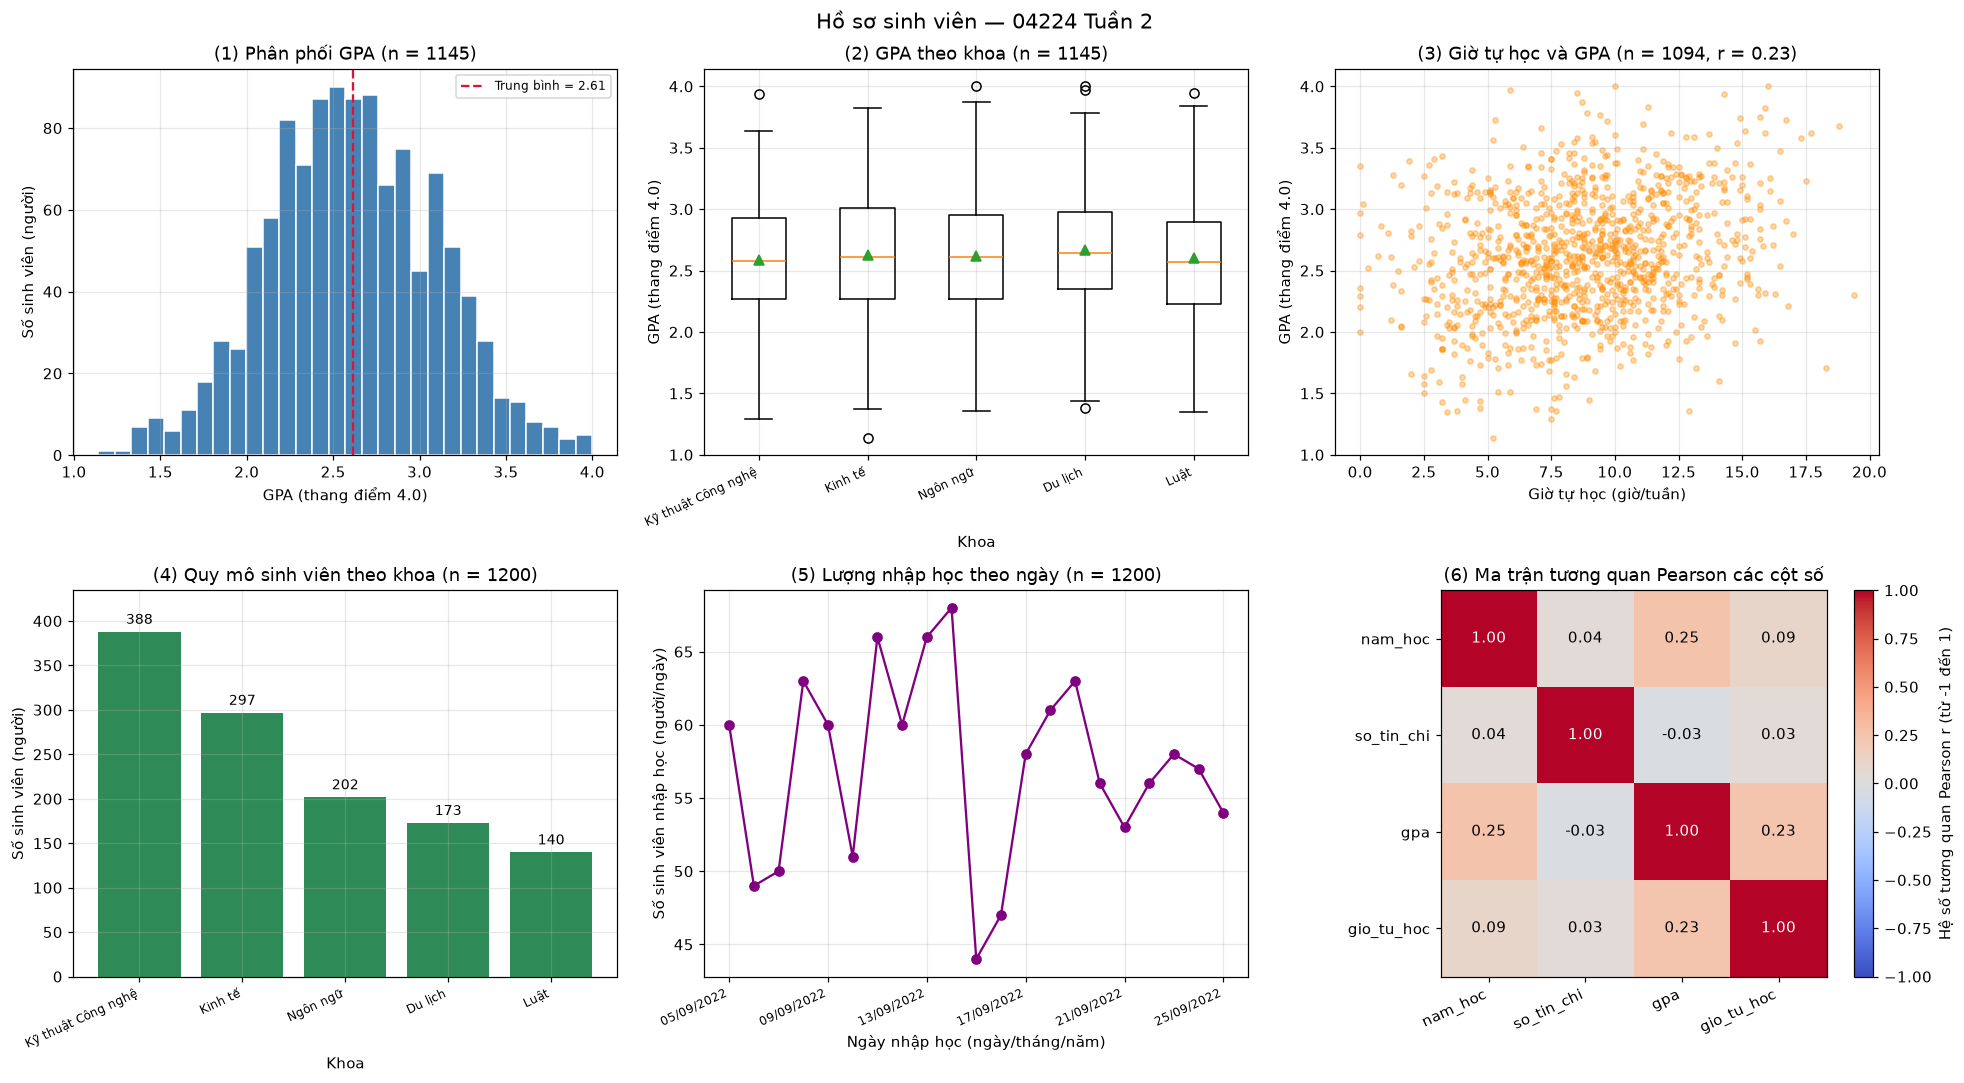

In [2]:
FIG_FILE = "tuan02_6bieudo.png"
sv_gpa = sv.dropna(subset=["gpa"])          # 1145 dòng có GPA

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# (1) Histogram — phân phối GPA -------------------------------------------
ax = axes[0, 0]
ax.hist(sv_gpa["gpa"], bins=30, color="steelblue", edgecolor="white")
ax.axvline(sv_gpa["gpa"].mean(), color="crimson", ls="--", lw=1.5,
           label="Trung bình = %.2f" % sv_gpa["gpa"].mean())
ax.legend(fontsize=8)
ax.set_xlabel("GPA (thang điểm 4.0)")
ax.set_ylabel("Số sinh viên (người)")
ax.set_title("(1) Phân phối GPA (n = %d)" % len(sv_gpa))

# (2) Box plot — GPA theo khoa --------------------------------------------
ax = axes[0, 1]
faculties = sv["khoa"].value_counts().index.tolist()
gpa_by_fac = [sv_gpa.loc[sv_gpa["khoa"] == f, "gpa"] for f in faculties]
ax.boxplot(gpa_by_fac, tick_labels=faculties, showmeans=True)
ax.set_xlabel("Khoa")
ax.set_ylabel("GPA (thang điểm 4.0)")
ax.set_title("(2) GPA theo khoa (n = %d)" % len(sv_gpa))
plt.setp(ax.get_xticklabels(), rotation=25, ha="right", fontsize=8)

# (3) Scatter — giờ tự học và GPA -----------------------------------------
ax = axes[0, 2]
d3 = sv.dropna(subset=["gpa", "gio_tu_hoc"])
ax.scatter(d3["gio_tu_hoc"], d3["gpa"], s=12, alpha=0.35, color="darkorange")
r = d3["gio_tu_hoc"].corr(d3["gpa"])
ax.set_xlabel("Giờ tự học (giờ/tuần)")
ax.set_ylabel("GPA (thang điểm 4.0)")
ax.set_title("(3) Giờ tự học và GPA (n = %d, r = %.2f)" % (len(d3), r))

# (4) Bar — số sinh viên theo khoa ----------------------------------------
ax = axes[1, 0]
counts = sv["khoa"].value_counts()
ax.bar(counts.index, counts.values, color="seagreen")
for i, v in enumerate(counts.values):
    ax.text(i, v + 5, str(v), ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, counts.max() * 1.12)
ax.set_xlabel("Khoa")
ax.set_ylabel("Số sinh viên (người)")
ax.set_title("(4) Quy mô sinh viên theo khoa (n = %d)" % counts.sum())
plt.setp(ax.get_xticklabels(), rotation=25, ha="right", fontsize=8)

# (5) Line — lượng nhập học theo ngày -------------------------------------
ax = axes[1, 1]
enrol = pd.to_datetime(sv["ngay_nhap_hoc"]).value_counts().sort_index()
ax.plot(enrol.index, enrol.values, marker="o", color="purple")
ax.set_xlabel("Ngày nhập học (ngày/tháng/năm)")
ax.set_ylabel("Số sinh viên nhập học (người/ngày)")
ax.set_title("(5) Lượng nhập học theo ngày (n = %d)" % enrol.sum())
ax.xaxis.set_major_formatter(matplotlib.dates.DateFormatter("%d/%m/%Y"))
plt.setp(ax.get_xticklabels(), rotation=25, ha="right", fontsize=8)

# (6) Heatmap — ma trận tương quan ----------------------------------------
ax = axes[1, 2]
num_cols = ["nam_hoc", "so_tin_chi", "gpa", "gio_tu_hoc"]
M = sv[num_cols].corr().to_numpy()
im = ax.imshow(M, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=25, ha="right")
ax.set_yticks(range(len(num_cols)))
ax.set_yticklabels(num_cols)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, "%.2f" % M[i, j], ha="center", va="center",
                color="white" if abs(M[i, j]) > 0.6 else "black", fontsize=10)
ax.set_title("(6) Ma trận tương quan Pearson các cột số")
ax.grid(False)
cbar = fig.colorbar(im, ax=ax, fraction=0.046)
cbar.set_label("Hệ số tương quan Pearson r (từ -1 đến 1)")

fig.suptitle("Hồ sơ sinh viên — 04224 Tuần 2", fontsize=14)
fig.tight_layout()
fig.savefig(FIG_FILE, dpi=300, bbox_inches="tight")
plt.show()


In [3]:
# --- Tự kiểm tra Task 1: trục không nhãn là một LỖI, không phải lựa chọn thẩm mỹ ---
assert axes.shape == (2, 3), "Phải là lưới 2x3"

for i, a in enumerate(axes.flat, 1):
    assert a.get_title().strip() != "", "Ô số %d chưa có title" % i

for i, a in enumerate(list(axes.flat)[:5], 1):
    assert a.get_xlabel().strip() != "", "Ô số %d chưa có nhãn trục X" % i
    assert a.get_ylabel().strip() != "", "Ô số %d chưa có nhãn trục Y" % i

# Ô số 6 là heatmap: tên biến nằm trên tick, còn đơn vị nằm ở colorbar
heat = axes[1, 2]
assert any(t.get_text().strip() for t in heat.get_xticklabels()), \
    "Heatmap chưa đặt tên biến lên trục"
extra_axes = [a for a in fig.axes if a not in list(axes.flat)]
assert extra_axes, "Heatmap chưa có colorbar"
assert any(a.get_ylabel().strip() for a in extra_axes), "Colorbar chưa có nhãn"

assert os.path.exists(FIG_FILE), "Chưa lưu file hình"
assert os.path.getsize(FIG_FILE) > 200_000, "File quá nhỏ — có chắc đã dùng dpi=300 chưa?"
print("Task 1 ĐẠT: 6 biểu đồ, đủ title + nhãn trục + colorbar có nhãn, hình 300 dpi đã lưu.")

Task 1 ĐẠT: 6 biểu đồ, đủ title + nhãn trục + colorbar có nhãn, hình 300 dpi đã lưu.


### Nhận định của bạn — mỗi biểu đồ một câu

1. **Histogram GPA:** GPA của 1145 sinh viên tập trung quanh 2.6 (trung bình 2.61). Chỉ khoảng 3% đạt trên 3.5, nên phần lớn sinh viên ở mức trung bình – khá.
2. **Box plot theo khoa:** Trung vị GPA của năm khoa chỉ lệch nhau khoảng 0.07 điểm (Luật 2.57 → Du lịch 2.64). Khoa hầu như không ảnh hưởng đến kết quả học tập.
3. **Scatter giờ tự học – GPA:** Tự học nhiều hơn đi kèm GPA cao hơn, nhưng r ≈ 0.23 là tương quan yếu. Giờ tự học chỉ giải thích khoảng 5% (r² ≈ 0.05) sự khác biệt về GPA.
4. **Bar quy mô khoa:** Kỹ thuật Công nghệ lớn nhất với 388 sinh viên, gần gấp ba Luật (140). Vì vậy khi so sánh giữa các khoa nên dùng tỉ lệ thay vì số tuyệt đối.
5. **Line nhập học:** Toàn bộ sinh viên nhập học trong ba tuần 05–25/09/2022, mỗi ngày dao động 44–68 người, không có ngày cao điểm rõ rệt. Việc nhập học được dàn đều.
6. **Heatmap tương quan:** GPA tương quan dương yếu với năm học (≈ 0.25) và giờ tự học (≈ 0.23). Số tín chỉ gần như không tương quan với biến nào (|r| ≤ 0.04), nên học nhiều tín chỉ không kéo GPA xuống.


---
# Task 2 — Hàm `profile(df)` (~25 phút)

**Mục tiêu.** Viết **một** hàm dùng được cho **mọi** DataFrame, trả về cho từng cột:

| Trường | Ý nghĩa |
|---|---|
| `dtype` | kiểu dữ liệu pandas đang hiểu |
| `n_missing` | số ô thiếu |
| `pct_missing` | tỉ lệ thiếu, tính theo % |
| `n_unique` | số giá trị duy nhất (không tính `NaN`) |
| `top_values` | 5 giá trị phổ biến nhất kèm số đếm |

**Các bước**

1. Hàm trả về một **DataFrame** (không phải `dict`, không phải chuỗi `print`) — để còn lọc, sắp xếp và đem đi dùng lại.
2. Index là tên cột, và **thứ tự cột phải giữ nguyên như trong `df`**.
3. Chạy trên cả `sinhvien.csv` lẫn `banhang_raw.csv`.
4. Hàm phải chịu được trường hợp biên: cột toàn `NaN`, và DataFrame rỗng (`len(df) == 0` — đừng chia cho 0).
5. `assert len(profile(df)) == df.shape[1]` — đúng một dòng cho mỗi cột.

> `df.describe()` **không** thay thế được hàm này: nó bỏ qua cột chuỗi và không cho biết tỉ lệ thiếu. Bạn sẽ dùng lại `profile()` ở Task 3 và ở các tuần sau.

**Kết quả mong đợi**

- `profile(sv)` — **9 dòng**. `gpa` thiếu **55 (4.58%)**, `gio_tu_hoc` thiếu **53 (4.42%)**, `tinh_tp` thiếu **14 (1.17%)**.
- `profile(raw)` — **8 dòng**, và bảng này đã đủ để lộ **bốn** khuyết tật trước khi bạn sửa dòng nào:

| Dấu hiệu trong bảng | Khuyết tật |
|---|---|
| `ma_don` có `n_unique = 900` nhưng `raw` có **928** dòng | có dòng trùng lặp |
| `kenh` có `n_unique = 4` | 4 cách viết cho 2 kênh thật |
| `thanh_tien` có `dtype = str` | số đang lưu dưới dạng chuỗi |
| `so_luong` có `dtype = float64` dù là số nguyên | có `NaN` nên pandas phải nới kiểu |

- Ô tự kiểm tra in `Task 2 ĐẠT: ...`

In [4]:
def profile(df, k=5):
    """Hồ sơ nhanh của một DataFrame bất kỳ — mỗi cột một dòng.

    Trả về DataFrame có index là tên cột và các cột:
      dtype, n_missing, pct_missing, n_unique, top_values
    """
    n = len(df)
    rows = []
    for col in df.columns:
        s = df[col]
        vc = s.value_counts().head(k)              # value_counts() mặc định bỏ NaN
        top = ", ".join("%r x%d" % (v, c) for v, c in vc.items())   # cột rỗng/toàn NaN -> ""
        n_missing = int(s.isna().sum())
        rows.append({
            "column":      col,
            "dtype":       str(s.dtype),
            "n_missing":   n_missing,
            "pct_missing": round(100 * n_missing / n, 2) if n > 0 else 0.0,   # tránh chia cho 0
            "n_unique":    int(s.nunique(dropna=True)),
            "top_values":  top,
        })
    return pd.DataFrame(rows, columns=["column", "dtype", "n_missing",
                                       "pct_missing", "n_unique",
                                       "top_values"]).set_index("column")

In [5]:
# --- Chạy trên cả hai tập dữ liệu ---
print("=" * 28, "sinhvien.csv", "=" * 28)
p_sv = profile(sv)
print(p_sv)

print()
print("=" * 28, "banhang_raw.csv", "=" * 28)
p_raw = profile(raw)
print(p_raw)

# --- Tự kiểm tra: đúng một dòng cho mỗi cột ---
assert len(p_sv) == sv.shape[1], "profile() phải trả về đúng 1 dòng cho 1 cột"
assert len(p_raw) == raw.shape[1], "profile() phải trả về đúng 1 dòng cho 1 cột"
assert list(p_sv.index) == list(sv.columns), "Thứ tự cột phải giữ nguyên"

# --- Phải chạy được với DataFrame BẤT KỲ, kể cả trường hợp biên ---
edge = pd.DataFrame({"a": [1, 1, 2], "b": [np.nan] * 3, "c": ["x", None, "x"]})
p_edge = profile(edge)
assert len(p_edge) == 3
assert p_edge.loc["b", "n_missing"] == 3 and p_edge.loc["b", "n_unique"] == 0
assert profile(pd.DataFrame(columns=["z"])).shape[0] == 1   # DataFrame rỗng
print("\nTask 2 ĐẠT: đúng 1 dòng/cột, chịu được cột toàn NaN và DataFrame rỗng.")

============================ sinhvien.csv ============================
                 dtype  n_missing  pct_missing  n_unique                                         top_values
column                                                                                                     
mssv             int64          0         0.00      1200  2200001 x1, 2200002 x1, 2200003 x1, 2200004 x1...
ho_ten             str          0         0.00       861  'Phạm Thị Dũng' x5, 'Hoàng Ngọc Sơn' x5, 'Huỳn...
khoa               str          0         0.00         5  'Kỹ thuật Công nghệ' x388, 'Kinh tế' x297, 'Ng...
nam_hoc          int64          0         0.00         4                     1 x361, 2 x318, 3 x285, 4 x236
tinh_tp            str         14         1.17         8  'TP. Hồ Chí Minh' x492, 'Hà Nội' x146, 'Đà Nẵn...
so_tin_chi       int64          0         0.00        13         23 x103, 24 x103, 19 x103, 16 x101, 18 x98
gpa            float64         55         4.58       226    2.61 

### Trước khi sang Task 3 — đọc bảng, đừng đọc dữ liệu thô

1. Hai cột có `dtype` sai với ý nghĩa thực tế. **`thanh_tien`** là số tiền nhưng có `dtype = str`, vì một số ô được ghi kiểu `"2.760.000 đ"`, có dấu chấm ngăn cách hàng nghìn và chữ `đ`. Chỉ cần một ô không đọc được thành số là pandas giữ cả cột dưới dạng chuỗi. **`so_luong`** là số nguyên nhưng có `dtype = float64`, vì cột có 30 ô `NaN` (3.23%) mà kiểu `int64` không chứa được `NaN`, nên pandas nới sang `float64`. Ngoài ra, **`ngay`** vẫn đang là `str` vì trộn hai định dạng (`2024-11-11` và `31/02/2024`) và có cả ngày không tồn tại như 31/02.
2. `ma_don` có **900** giá trị duy nhất, trong khi tệp có **928** dòng. Mã đơn hàng lẽ ra phải duy nhất, nên 28 dòng dư là đơn bị ghi trùng (ví dụ `DH00653` xuất hiện 2 lần). Nếu không bỏ trùng thì doanh thu sẽ bị tính hai lần cho những đơn này.
3. `kenh` có **4** giá trị duy nhất (`Online`, `Cửa hàng`, `ONLINE`, `Cua hang`), nhưng thực tế chỉ có **2** kênh: **Online** và **Cửa hàng**. Hai giá trị còn lại chỉ khác cách viết (chữ hoa, thiếu dấu), nên cần chuẩn hóa trước khi nhóm theo kênh.

---
# Task 3 — Làm sạch `banhang_raw.csv` (~60 phút)

Đây là bài trọng tâm của buổi. Tệp này **cố ý bị làm bẩn** theo đúng những kiểu lỗi bạn sẽ gặp ngoài thực tế: xuất từ nhiều nguồn, nhiều người nhập, nhiều định dạng địa phương.

**Quy tắc làm việc**

1. **Soi trước, sửa sau.** Đừng gõ `drop_duplicates()` ở dòng đầu tiên. Lập hồ sơ, tìm cho hết vấn đề, rồi mới sửa.
2. **Đừng xóa dòng khi chưa cần.** Một ô hỏng không làm hỏng bảy ô còn lại của cùng một dòng.
3. **Mỗi bước là một quyết định.** Ghi ngay vào nhật ký ở cuối Task 3, đừng để đến cuối buổi mới nhớ lại.

**Bảng kết quả mong đợi — dùng để tự chấm**

| Bước | Việc | Kết quả mong đợi |
|:--:|---|---|
| 3.1 | Nạp và lập hồ sơ | `(928, 8)`; 28 dòng trùng; `kenh` 4 cách viết; `thanh_tien` 166 dòng chuỗi; `ngay` 120 dòng DD/MM |
| 3.2 | Bỏ trùng lặp | bỏ **28** dòng → còn **900**; `ma_don` duy nhất |
| 3.3 | Chuẩn hóa `kenh` | 4 → **2** nhãn: `Online` **570**, `Cửa hàng` **330** |
| 3.4 | `thanh_tien` sang số | `dtype` `str` → `int64`; tổng **3.068.440.000 đ**; min 250.000, max 16.000.000 |
| 3.5 | Phân tích `ngay` | 785 dòng ISO + 115 dòng DD/MM; **7 NaT**, đều là `31/02/2024`; khoảng 2024-01-01 → 2024-12-29 |
| 3.6 | Xử lý thiếu | `so_luong` **30 → 0**; `tinh_tp` **52 → 0** (9 nhãn) |
| 3.7 | Xử lý ngoại lai | IQR gắn cờ **7** dòng (4 dòng `500`, 3 dòng `-2`) → `so_luong` còn ∈ [1, 5], `int64` |
| 3.8 | Kiểm chứng chéo | **0/900** dòng lệch giữa `so_luong × don_gia` và `thanh_tien` |

**Kết quả cuối cùng.** `(900, 8)`, đúng **7** ô thiếu trên toàn bảng (cả 7 đều ở cột `ngay`), và tệp `banhang_sach.csv` đã lưu.

> Một gợi ý duy nhất, và là gợi ý quan trọng nhất của buổi: **cột `thanh_tien` không chỉ là dữ liệu, nó còn là bằng chứng.** Hãy nghĩ xem nó có quan hệ gì với `so_luong` và `don_gia`, và quan hệ đó giúp được gì ở bước 3.6 và 3.7.

## 3.1 — Nạp và lập hồ sơ: tìm cho hết vấn đề trước khi sửa

Dùng lại `profile()` của Task 2. Sau đó đếm riêng bốn thứ: dòng trùng, cách viết của `kenh`, số dòng `thanh_tien` còn chữ `đ`, số dòng `ngay` theo định dạng `DD/MM/YYYY`.

**Kết quả mong đợi.** `(928, 8)` · **28** dòng trùng · `kenh`: `'Online'` 510, `'Cửa hàng'` 279, `'ONLINE'` 78, `'Cua hang'` 61 · **166** dòng `thanh_tien` dạng chuỗi · **120** dòng `ngay` dạng DD/MM.

In [6]:
# --- 3.1 Nạp và soi kỹ TRƯỚC khi sửa bất cứ thứ gì ---
df = load_csv("banhang_raw.csv")
print("Kích thước:", df.shape)
print()
print(profile(df))          # dùng lại hàm vừa viết ở Task 2
print()

n_dup = int(df.duplicated().sum())
print("Số dòng trùng lặp hoàn toàn:", n_dup)

print("\nCác cách viết của `kenh`:")
for k, v in df["kenh"].value_counts(dropna=False).items():
    print("   %-12r x%d" % (k, v))

n_text_money = int(df["thanh_tien"].astype(str).str.contains("đ", regex=False).sum())
print("\nSố dòng `thanh_tien` còn chữ 'đ':", n_text_money)

n_dmy = int(df["ngay"].str.fullmatch(r"\d{2}/\d{2}/\d{4}").sum())
print("Số dòng `ngay` dạng DD/MM/YYYY :", n_dmy)

assert df.shape == (928, 8)
assert n_dup == 28 and df["kenh"].nunique() == 4
assert n_text_money == 166 and n_dmy == 120

Kích thước: (928, 8)

              dtype  n_missing  pct_missing  n_unique                                         top_values
column                                                                                                  
ma_don          str          0         0.00       900  'DH00653' x2, 'DH00888' x2, 'DH00594' x2, 'DH0...
san_pham        str          0         0.00         6  'Bàn phím' x170, 'Màn hình' x158, 'Ổ cứng SSD'...
so_luong    float64         30         3.23         7   1.0 x204, 4.0 x180, 3.0 x178, 2.0 x165, 5.0 x164
don_gia       int64          0         0.00         6  450000 x170, 3200000 x158, 1450000 x154, 89000...
kenh            str          0         0.00         4  'Online' x510, 'Cửa hàng' x279, 'ONLINE' x78, ...
tinh_tp         str         54         5.82         8  'Lâm Đồng' x122, 'TP. Hồ Chí Minh' x120, 'Cần ...
ngay            str          0         0.00       415  '31/02/2024' x7, '2024-11-11' x7, '2024-02-29'...
thanh_tien      str          0   

## 3.2 — Bỏ dòng trùng lặp hoàn toàn

Ô dưới in trước một cặp dòng trùng để bạn nhìn tận mắt: hai dòng giống nhau ở **cả tám cột**, kể cả `ma_don`. Đó là lỗi lặp khi gộp tệp, không phải hai đơn hàng khác nhau.

Phân biệt hai lệnh, vì chúng mang ý nghĩa khác nhau:
- `drop_duplicates()` — bỏ dòng giống nhau ở **mọi** cột.
- `drop_duplicates(subset="ma_don")` — bỏ dòng trùng **mã đơn**, kể cả khi các cột khác khác nhau.

Ở tệp này hai lệnh cho cùng kết quả. Nhưng nếu hai dòng cùng `ma_don` mà **khác** `so_luong` thì sao? Đó không còn là trùng lặp mà là **xung đột dữ liệu** — phải điều tra, không được lặng lẽ giữ lại một dòng.

**Kết quả mong đợi.** Bỏ **28** dòng, `928 → 900`, `ma_don` trở thành duy nhất.

In [7]:
# --- 3.2 Bỏ các dòng trùng lặp hoàn toàn ---
before = len(df)
print("Ví dụ một cặp trùng lặp (trùng cả `ma_don`):")
print(df[df.duplicated(subset="ma_don", keep=False)].sort_values("ma_don").head(4))

# Kiểm tra trước: trùng `ma_don` có luôn là trùng cả 8 cột không? (nếu không -> xung đột dữ liệu)
assert df.duplicated(subset="ma_don").sum() == df.duplicated().sum(), \
    "Có mã đơn trùng nhưng khác nội dung — phải điều tra, không được bỏ bừa"

df = df.drop_duplicates().reset_index(drop=True)
removed = before - len(df)
print("\nĐã bỏ %d dòng trùng lặp: %d -> %d" % (removed, before, len(df)))

assert removed == 28, "Phải bỏ đúng 28 dòng, đang bỏ %d" % removed
assert len(df) == 900, "Còn lại phải là 900 dòng"
assert df.duplicated().sum() == 0
assert df["ma_don"].is_unique, "Mỗi `ma_don` chỉ được xuất hiện một lần"

Ví dụ một cặp trùng lặp (trùng cả `ma_don`):
      ma_don    san_pham  so_luong  don_gia    kenh          tinh_tp        ngay   thanh_tien
54   DH00061    Tai nghe       4.0   690000  ONLINE         Đồng Nai  2024-11-19      2760000
296  DH00061    Tai nghe       4.0   690000  ONLINE         Đồng Nai  2024-11-19      2760000
791  DH00064  Ổ cứng SSD       2.0  1450000  Online  TP. Hồ Chí Minh  2024-02-11  2.900.000 đ
152  DH00064  Ổ cứng SSD       2.0  1450000  Online  TP. Hồ Chí Minh  2024-02-11  2.900.000 đ

Đã bỏ 28 dòng trùng lặp: 928 -> 900


## 3.3 — Chuẩn hóa `kenh` về đúng 2 nhãn

Bốn cách viết trong tệp là ba loại lỗi khác nhau, và mỗi loại cần một cách xử lý khác nhau:

| Cách viết | Loại lỗi | Công cụ |
|---|---|---|
| `Online` | chuẩn | — |
| `ONLINE` | sai hoa/thường | `.str.casefold()` |
| `Cửa hàng` | chuẩn | — |
| `Cua hang` | **mất dấu tiếng Việt** | không có hàm nào tự sửa → **ánh xạ tay** |

Thêm `.str.strip()` ở đầu chuỗi xử lý: tệp này không có dấu cách thừa, nhưng một tệp xuất từ Excel thì gần như chắc chắn có, và `.strip()` không làm hỏng gì.

**Cái bẫy.** `.str.title()` trông như lời giải nhưng không phải: `"Cua hang".title()` cho `"Cua Hang"`, vẫn khác `"Cửa hàng"`. Không có hàm chuẩn hóa nào đoán được dấu tiếng Việt — bạn phải khai báo ánh xạ.

**Vì sao `.map()` chứ không phải `.replace()`.** `map()` trả về `NaN` cho khóa không có trong từ điển. Đó là **tính năng**: nếu tuần sau tệp xuất hiện thêm một cách viết mới, `assert` bên dưới sẽ bắt được ngay. `replace()` sẽ lặng lẽ giữ nguyên giá trị lạ.

**Kết quả mong đợi.** 4 → **2** nhãn: `Online` = **570** (= 493 + 77) và `Cửa hàng` = **330** (= 272 + 58), tính trên 900 dòng còn lại sau bước 3.2. Không có `NaN`.

In [8]:
# --- 3.3 Chuẩn hoá `kenh` về đúng 2 nhãn ---
print("Trước:", ", ".join("%r x%d" % (k, v) for k, v in df["kenh"].value_counts(dropna=False).items()))

# Bẫy: .str.title() không cứu được chuỗi mất dấu
print("\nBẫy:", repr("Cua hang".title()), "!=", repr("Cửa hàng"))

key = df["kenh"].str.strip().str.casefold()
print("Sau strip + casefold còn lại:", sorted(key.unique()))

KENH_MAP = {
    "online":   "Online",
    "cửa hàng": "Cửa hàng",
    "cua hang": "Cửa hàng",     # bản mất dấu -> ánh xạ tay
}

df["kenh"] = key.map(KENH_MAP)

print("\nSau :", ", ".join("%r x%d" % (k, v) for k, v in df["kenh"].value_counts(dropna=False).items()))
assert df["kenh"].nunique() == 2, "Phải còn đúng 2 nhãn, đang có %d" % df["kenh"].nunique()
assert df["kenh"].isna().sum() == 0, "map() sinh ra NaN -> còn chính tả chưa liệt kê trong KENH_MAP"
assert int((df["kenh"] == "Online").sum()) == 570
assert int((df["kenh"] == "Cửa hàng").sum()) == 330

Trước: 'Online' x493, 'Cửa hàng' x272, 'ONLINE' x77, 'Cua hang' x58

Bẫy: 'Cua Hang' != 'Cửa hàng'
Sau strip + casefold còn lại: ['cua hang', 'cửa hàng', 'online']

Sau : 'Online' x570, 'Cửa hàng' x330


## 3.4 — `thanh_tien`: từ chuỗi tiền tệ sang số

162 dòng (sau khi lọc trùng) đang ghi kiểu `"2.760.000 đ"`. Ba việc phải làm trước khi ép kiểu: bỏ chữ `đ`, bỏ dấu `.`, và `.strip()`.

**Cái bẫy chết người.** Trong tiếng Việt dấu `.` là **phân cách hàng nghìn**, không phải dấu thập phân. `"2.760.000"` là hai triệu bảy trăm sáu mươi nghìn, không phải 2.76. Nếu bạn đưa thẳng chuỗi này cho `pd.to_numeric` mà không bỏ dấu chấm, kết quả sẽ sai **ba bậc độ lớn** — và không có thông báo lỗi nào.

**Cái bẫy thứ hai.** `.str.replace(".", "")` mặc định hiểu `"."` là **regex**, mà `.` trong regex nghĩa là "ký tự bất kỳ" → xóa sạch cả chuỗi. Bắt buộc `regex=False`.

**Vì sao giữ `errors="raise"`.** `errors="coerce"` sẽ biến mọi thứ không ép được thành `NaN` một cách im lặng. Ở bước làm sạch, im lặng là điều tệ nhất: nếu còn ký tự lạ, ta muốn chương trình dừng lại và nói ra.

**Kết quả mong đợi.** `dtype`: `str` → `int64` · không còn `NaN` · min **250.000**, max **16.000.000** · tổng **3.068.440.000 đ**.

In [9]:
# --- 3.4 `thanh_tien`: từ chuỗi tiền tệ sang số ---
text_rows = df["thanh_tien"].astype(str).str.contains("đ")
print("Số dòng đang ghi dạng chuỗi:", int(text_rows.sum()))
print("Ví dụ:", df.loc[text_rows, "thanh_tien"].head(3).tolist())

cleaned = (df["thanh_tien"].astype(str)
           .str.replace("đ", "", regex=False)     # 1. bỏ chữ "đ"
           .str.replace(".", "", regex=False)     # 2. bỏ dấu chấm phân cách nghìn
           .str.strip())                          # 3. bỏ dấu cách thừa
df["thanh_tien"] = pd.to_numeric(cleaned, errors="raise").astype("int64")

print("\ndtype mới :", df["thanh_tien"].dtype)
print("min / max :", df["thanh_tien"].min(), "/", df["thanh_tien"].max())
print("tổng doanh thu:", format(int(df["thanh_tien"].sum()), ",").replace(",", "."), "đ")

assert pd.api.types.is_numeric_dtype(df["thanh_tien"])
assert df["thanh_tien"].isna().sum() == 0
assert int(df["thanh_tien"].sum()) == 3_068_440_000

Số dòng đang ghi dạng chuỗi: 162
Ví dụ: ['2.760.000 đ', '1.380.000 đ', '12.800.000 đ']

dtype mới : int64
min / max : 250000 / 16000000
tổng doanh thu: 3.068.440.000 đ


## 3.5 — `ngay`: hai định dạng, và 7 ngày không tồn tại

Cột này trộn `YYYY-MM-DD` (785 dòng) với `DD/MM/YYYY` (115 dòng), cộng thêm **7 dòng ghi `31/02/2024`** — một ngày không hề tồn tại.

Ô dưới cho bạn chạy qua hai cái bẫy trước khi làm đúng:

- **Bẫy 1.** `pd.to_datetime(df["ngay"])` ném `ValueError`. Đọc kỹ thông báo — nó nói thẳng vấn đề.
- **Bẫy 2.** Thêm `errors="coerce"` thì hết lỗi. Nhưng hết bằng cách nào? Nó cho ra **120** `NaT`. Chỉ có 7 ngày thật sự sai. **113 ngày hợp lệ vừa bị hủy trong im lặng** vì pandas khóa định dạng theo dòng đầu tiên (ISO) rồi coi mọi dòng `DD/MM` là rác.

Cách đúng là nói rõ hai điều với pandas: `format="mixed"` (cột này có nhiều hơn một định dạng) và `dayfirst=True` (`03/04/2024` là **3 tháng 4**, không phải 4 tháng 3).

**Quyết định bạn phải đưa ra, và bảo vệ bằng chữ:** 7 dòng có ngày không tồn tại — **xóa dòng, hay giữ dòng và chỉ để `ngay = NaT`?** Trước khi trả lời, hãy đo cái giá: tổng `thanh_tien` của 7 dòng đó là bao nhiêu?

**Kết quả mong đợi.** Bẫy 2 cho **120** NaT. Cách đúng cho **7** NaT, cả 7 đều từ `'31/02/2024'`. Vẫn đủ **900** dòng. Khoảng ngày: **2024-01-01 → 2024-12-29**.

In [10]:
# --- 3.5 `ngay`: hai định dạng + 7 ngày không tồn tại ---
iso = int(df["ngay"].str.fullmatch(r"\d{4}-\d{2}-\d{2}").sum())
dmy = int(df["ngay"].str.fullmatch(r"\d{2}/\d{2}/\d{4}").sum())
print("YYYY-MM-DD: %d dòng | DD/MM/YYYY: %d dòng" % (iso, dmy))

# Bẫy 1 — gọi thẳng thì vỡ. Chạy đi, đọc kỹ thông báo lỗi.
try:
    pd.to_datetime(df["ngay"])
except ValueError as e:
    print("\n[Bẫy 1] pd.to_datetime(df['ngay']) ->", type(e).__name__)
    print("        ", str(e).splitlines()[0][:88])

# Bẫy 2 — errors="coerce" làm lỗi biến mất. Nhưng nó biến mất bằng cách nào?
trap = pd.to_datetime(df["ngay"], errors="coerce")
print("[Bẫy 2] chỉ thêm errors='coerce' -> NaT:", int(trap.isna().sum()))
print("        trong đó dòng DD/MM hợp lệ bị huỷ:",
      int((trap.isna() & (df["ngay"] != "31/02/2024")).sum()))

# Bẫy 3 — format="mixed" + dayfirst=True áp dayfirst cho CẢ ngày ISO:
#          "2024-06-10" (10/6) bị đọc thành 6/10. Không NaT, không lỗi, không assert nào bắt được.
mixed = pd.to_datetime(df["ngay"], format="mixed", dayfirst=True, errors="coerce")

# Cách đúng: mỗi định dạng đọc bằng đúng format của nó, rồi ghép lại
parsed_iso = pd.to_datetime(df["ngay"], format="%Y-%m-%d", errors="coerce")
parsed_dmy = pd.to_datetime(df["ngay"], format="%d/%m/%Y", errors="coerce")
parsed = parsed_iso.fillna(parsed_dmy)

print("[Bẫy 3] format='mixed' + dayfirst=True -> NaT: %d, nhưng %d ngày ISO bị ĐẢO ngày/tháng"
      % (int(mixed.isna().sum()), int(((mixed != parsed) & parsed.notna()).sum())))
print("[Đúng ] -> NaT:", int(parsed.isna().sum()))
print("        giá trị không đọc được:", df.loc[parsed.isna(), "ngay"].value_counts().to_dict())

# Cái giá của việc xoá 7 dòng đó
bad = parsed.isna()
cost = int(df.loc[bad, "thanh_tien"].sum())
print("\nTổng thanh_tien của %d dòng ngày sai: %s đ (%.2f%% doanh thu)"
      % (int(bad.sum()), format(cost, ",").replace(",", "."),
         100 * cost / df["thanh_tien"].sum()))

# Kiểm chứng hai chiều: đọc xong in ngược lại phải ra đúng chuỗi gốc
ok = parsed.notna()
round_trip = parsed_iso.dt.strftime("%Y-%m-%d").fillna(parsed_dmy.dt.strftime("%d/%m/%Y"))
assert (round_trip[ok] == df.loc[ok, "ngay"]).all(), "Có ngày bị đọc sai ngày/tháng"

# Quyết định: GIỮ dòng, để ngay = NaT (xem lập luận ở ô bên dưới)
df["ngay"] = parsed
print("Khoảng ngày:", df["ngay"].min().date(), "->", df["ngay"].max().date())

assert df["ngay"].isna().sum() == 7
assert str(df["ngay"].min().date()) == "2024-01-01"
assert str(df["ngay"].max().date()) == "2024-12-29"
assert len(df) == 900, "Vẫn phải còn 900 dòng sau bước này"

YYYY-MM-DD: 785 dòng | DD/MM/YYYY: 115 dòng

[Bẫy 1] pd.to_datetime(df['ngay']) -> ValueError
         time data "17/04/2024" doesn't match format "%Y-%m-%d". You might want to try:
[Bẫy 2] chỉ thêm errors='coerce' -> NaT: 115
        trong đó dòng DD/MM hợp lệ bị huỷ: 108
[Bẫy 3] format='mixed' + dayfirst=True -> NaT: 7, nhưng 274 ngày ISO bị ĐẢO ngày/tháng
[Đúng ] -> NaT: 7
        giá trị không đọc được: {'31/02/2024': 7}

Tổng thanh_tien của 7 dòng ngày sai: 44.400.000 đ (1.45% doanh thu)
Khoảng ngày: 2024-01-01 -> 2024-12-29


### Quyết định của bạn về 7 ngày không tồn tại

1. **113 dòng kia đi đâu?** Chúng là những ngày `DD/MM/YYYY` **hoàn toàn hợp lệ** (vd `17/04/2024`). Khi không được nói định dạng, pandas suy định dạng từ dòng đầu tiên (`YYYY-MM-DD`) rồi áp cho cả cột; mọi dòng `DD/MM` không khớp nên bị `errors="coerce"` biến thành `NaT` trong im lặng. *(Trên 900 dòng sau khi bỏ trùng, notebook đo được 115 `NaT` ở Bẫy 2, trong đó 108 ngày hợp lệ bị hủy; con số 120/113 trong đề là tính trên 928 dòng gốc — cùng một hiện tượng.)*

   **Lưu ý thêm — bẫy thứ ba.** Cách gợi ý `format="mixed", dayfirst=True` cho đúng 7 `NaT` nhưng lại áp `dayfirst` cho **cả ngày ISO**: `2024-06-10` (10/6) bị đọc thành 6/10. Notebook đo được **274 ngày ISO bị đảo ngày/tháng** mà không có lỗi hay `NaT` nào báo hiệu, và các `assert` min/max vẫn qua. Vì vậy mình đọc riêng từng định dạng (`%Y-%m-%d` và `%d/%m/%Y`), ghép lại, rồi kiểm tra hai chiều: in ngày đã đọc ra chuỗi thì phải khớp chuỗi gốc ở cả 893 dòng.
2. **Giữ dòng, để `ngay = NaT`.**
3. **Lý do:** chỉ có **một ô** hỏng; bảy ô còn lại (mã đơn, sản phẩm, số lượng, đơn giá, kênh, tỉnh, thành tiền) đều đúng và qua được kiểm chứng chéo ở 3.8. Xóa dòng là vứt đi **44.400.000 đ (1,45% doanh thu)** của những đơn hàng có thật. Ngoài ra ta cũng không được "đoán" ngày đúng (28/02? 01/03? 31/03?) — không có căn cứ nào, nên `NaT` là cách trung thực nhất để ghi nhận "không biết".
4. **Ảnh hưởng:** (a) **tổng doanh thu cả năm giữ nguyên 3.068.440.000 đ** — đúng với số tiền thật đã thu. (b) Trên **biểu đồ theo tháng**, 7 dòng `NaT` sẽ không rơi vào tháng nào, nên tổng các tháng thấp hơn tổng năm 44,4 triệu đ; khi báo cáo phải ghi chú rõ "7 đơn (44,4 triệu) không xác định được ngày", hoặc thêm một cột "Không rõ ngày" để hai con số khớp nhau.

## 3.6 — Giá trị thiếu: `so_luong` (30) và `tinh_tp` (52)

**Đừng gõ `fillna()` ngay.** Phản xạ "thiếu thì điền trung bình" là phản xạ sai. Câu hỏi đầu tiên luôn là:

> **Giá trị này có thể SUY RA được từ cột khác không?**

Bạn đang có `thanh_tien` (đã là số từ bước 3.4) và `don_gia`. Hãy tính `thanh_tien / don_gia` và nhìn kỹ kết quả:
- Nó có phải số nguyên ở **mọi** dòng không?
- Khoảng giá trị của nó có hợp lý với một đơn hàng bán lẻ không?
- Trong những dòng `so_luong` **đang có sẵn**, bao nhiêu dòng khớp với phép suy luận này?

Nếu con số cuối cùng rất lớn, bạn vừa tìm được một **cột kiểm chứng đáng tin**, và 30 ô thiếu kia không cần ước lượng — chúng **khôi phục được chính xác**. Điền trung bình khi giá trị thật suy ra được là vứt bỏ thông tin.

**`tinh_tp` thì khác:** không cột nào suy ra được tỉnh/thành. Ở đây bạn buộc phải chọn, và phải nêu lý do:

| Lựa chọn | Hệ quả |
|---|---|
| `dropna()` | mất 52 dòng = **5,8%** doanh thu, chỉ vì thiếu một ô địa lý |
| `fillna(mode)` | bịa thêm 52 đơn cho `Lâm Đồng` → bảng xếp hạng doanh thu theo tỉnh **sai** |
| nhãn riêng `"Không rõ"` | giữ đủ 900 dòng, và giữ được sự thật "ta không biết" |

**Kết quả mong đợi.** `thanh_tien / don_gia` là số nguyên ở cả 900 dòng, nằm trong **[1, 5]**; **863/900** dòng đã khớp sẵn. `so_luong` thiếu **30 → 0**. `tinh_tp` thiếu **52 → 0**, `nunique` = **9**.

In [11]:
# --- 3.6 Giá trị thiếu: `so_luong` (30) và `tinh_tp` (52) ---
print("so_luong thiếu:", int(df["so_luong"].isna().sum()))
print("tinh_tp  thiếu:", int(df["tinh_tp"].isna().sum()))

# ĐỪNG gõ fillna() ngay. Câu hỏi đầu tiên luôn là:
#   "Giá trị này có SUY RA được từ cột khác không?"
qty_implied = df["thanh_tien"] / df["don_gia"]
print("\nthanh_tien / don_gia là số nguyên ở mọi dòng:", bool((qty_implied % 1 == 0).all()))
print("Khoảng giá trị suy ra: [%d, %d]" % (qty_implied.min(), qty_implied.max()))

have = df["so_luong"].notna()
n_match = int((df.loc[have, "so_luong"] == qty_implied[have]).sum())
print("Dòng có sẵn so_luong và KHỚP với suy luận: %d / %d  (tổng %d dòng)"
      % (n_match, int(have.sum()), len(df)))

# Suy ra được chính xác -> khôi phục, KHÔNG ước lượng
need = df["so_luong"].isna()
df.loc[need, "so_luong"] = qty_implied[need]

# `tinh_tp` không suy ra được -> nhãn riêng, giữ sự thật "không biết"
print("Doanh thu của các dòng thiếu tinh_tp: %.2f%%"
      % (100 * df.loc[df["tinh_tp"].isna(), "thanh_tien"].sum() / df["thanh_tien"].sum()))
df["tinh_tp"] = df["tinh_tp"].fillna("Không rõ")

print("\nso_luong thiếu sau khi xử lý:", int(df["so_luong"].isna().sum()))
print("tinh_tp  thiếu sau khi xử lý:", int(df["tinh_tp"].isna().sum()),
      "| số nhãn:", df["tinh_tp"].nunique())

assert df["so_luong"].isna().sum() == 0
assert df["tinh_tp"].isna().sum() == 0
assert df["tinh_tp"].nunique() == 9                      # 8 tỉnh/thành + 1 nhãn "không rõ"

so_luong thiếu: 30
tinh_tp  thiếu: 52

thanh_tien / don_gia là số nguyên ở mọi dòng: True
Khoảng giá trị suy ra: [1, 5]
Dòng có sẵn so_luong và KHỚP với suy luận: 863 / 870  (tổng 900 dòng)
Doanh thu của các dòng thiếu tinh_tp: 5.81%

so_luong thiếu sau khi xử lý: 0
tinh_tp  thiếu sau khi xử lý: 0 | số nhãn: 9


### Lập luận của bạn về hai cột thiếu

1. `thanh_tien / don_gia` là **số nguyên ở cả 900 dòng**, nằm trong **[1, 5]** — rất hợp lý với đơn bán lẻ. Trong 870 dòng có sẵn `so_luong`, **863 dòng khớp tuyệt đối**; 7 dòng lệch chính là 7 ngoại lai `500` / `-2` sẽ xử lý ở 3.7. Vậy `thanh_tien` là một cột kiểm chứng đáng tin, và 30 ô thiếu được **khôi phục chính xác** bằng `thanh_tien / don_gia`.
2. **Không dùng `fillna(median)`** vì giá trị thật **đã suy ra được**. Điền trung vị (= 3) sẽ sai ở phần lớn trong 30 dòng, và làm hỏng ràng buộc kế toán `so_luong × don_gia = thanh_tien` → bước 3.8 sẽ báo lệch. Ước lượng chỉ dùng khi không còn cách nào biết giá trị thật.
3. `tinh_tp`: chọn **nhãn riêng `"Không rõ"`**.
4. **Lý do:** không có cột nào suy ra được tỉnh/thành. `dropna()` sẽ vứt 52 đơn (**≈ 5,8% doanh thu**) dù mọi ô khác đều đúng → tổng doanh thu, doanh thu theo kênh, theo sản phẩm đều bị hụt. `fillna(mode)` sẽ gán cả 52 đơn cho `Lâm Đồng` (tỉnh đông nhất) → Lâm Đồng bị thổi phồng và **bảng xếp hạng doanh thu theo tỉnh sai**, mà sai một cách không ai nhìn thấy. Nhãn `"Không rõ"` giữ đủ 900 dòng, tổng doanh thu đúng, và nói thật với người đọc rằng có 5,8% doanh thu chưa gắn được địa lý.

## 3.7 — Ngoại lai: 4 dòng `500` và 3 dòng `-2`

Hàng rào IQR gắn cờ 7 dòng. Nhưng hãy nhớ:

> **IQR chỉ nói CHỖ NÀO cần nhìn. Nó không nói điều gì SAI.** Và quan trọng hơn: **một giá trị ngoại lai không mặc nhiên là một giá trị sai.**

Một đơn hàng 500 chiếc hoàn toàn có thể là thật — doanh nghiệp mua sỉ cho cả văn phòng. Một số lượng âm hoàn toàn có thể là thật — hàng trả lại thường được ghi bằng số âm. Nếu bạn cắt bỏ mọi thứ nằm ngoài hàng rào IQR, bạn sẽ xóa mất chính những giao dịch đáng chú ý nhất.

Vậy nên đừng phán đoán bằng cảm tính. Hãy **kiểm chứng giả thuyết bằng dữ liệu**:

- Nếu `500` là một đơn sỉ **thật**, thì `thanh_tien` phải bằng `500 × don_gia`. Nó có bằng không?
- Nếu `-2` là một đơn hàng trả lại **thật**, thì `thanh_tien` phải mang dấu **âm**. Nó có âm không?

Trả lời hai câu đó xong, bạn sẽ biết mỗi dòng là lỗi nhập liệu hay giao dịch thật — và biết bằng **bằng chứng**, không phải bằng phỏng đoán.

Nếu là lỗi nhập liệu: nhớ rằng "sửa" không đồng nghĩa với "xóa". Giá trị đúng có khôi phục được không?

**Kết quả mong đợi.** IQR gắn cờ đúng **7** dòng. Sau khi sửa: `so_luong` ∈ **[1, 5]**, `dtype` = **`int64`**, không còn giá trị `500` hay giá trị âm, và vẫn đủ **900** dòng.

In [12]:
# --- 3.7 Ngoại lai: 4 dòng `500` và 3 dòng `-2` ---
q1, q3 = df["so_luong"].quantile([0.25, 0.75])
iqr = q3 - q1
low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
flag = (df["so_luong"] < low) | (df["so_luong"] > high)
print("Hàng rào IQR: [%.1f, %.1f] -> gắn cờ %d dòng" % (low, high, int(flag.sum())))
print("IQR chỉ NÓI ĐÂU, không nói TẠI SAO. Phải đối chiếu với bằng chứng.\n")

suspect = df[flag].copy()
suspect["qty_implied"] = (suspect["thanh_tien"] / suspect["don_gia"]).astype(int)
suspect["neu_that"] = suspect["so_luong"] * suspect["don_gia"]    # thanh_tien PHẢI bằng nếu so_luong đúng
print(suspect[["ma_don", "san_pham", "so_luong", "don_gia", "thanh_tien",
               "neu_that", "qty_implied"]].to_string(index=False))

# Bằng chứng:
#   - 500 là đơn sỉ thật thì thanh_tien = 500 x don_gia (hàng trăm triệu). Thực tế chỉ vài triệu.
#   - -2 là hàng trả thật thì thanh_tien phải ÂM. Thực tế thanh_tien đều DƯƠNG.
print("\nNhóm 500: thanh_tien == 500 x don_gia ở", int((suspect["thanh_tien"] == suspect["neu_that"]).sum()),
      "/", int((suspect["so_luong"] == 500).sum()), "dòng")
print("Nhóm -2 : thanh_tien < 0 ở", int((suspect.loc[suspect["so_luong"] < 0, "thanh_tien"] < 0).sum()),
      "/", int((suspect["so_luong"] < 0).sum()), "dòng")

# Kết luận: cả 7 là lỗi nhập liệu -> khôi phục giá trị đúng từ thanh_tien / don_gia, không xoá dòng
df.loc[flag, "so_luong"] = (df.loc[flag, "thanh_tien"] / df.loc[flag, "don_gia"]).round()
df["so_luong"] = df["so_luong"].astype("int64")

print("\nso_luong sau khi sửa:", df["so_luong"].value_counts().sort_index().to_dict())
assert int(flag.sum()) == 7
assert df["so_luong"].between(1, 5).all(), "so_luong phải nằm trong 1..5"
assert df["so_luong"].dtype == "int64"
assert int((df["so_luong"] == 500).sum()) == 0 and int((df["so_luong"] < 0).sum()) == 0

Hàng rào IQR: [-1.0, 7.0] -> gắn cờ 7 dòng
IQR chỉ NÓI ĐÂU, không nói TẠI SAO. Phải đối chiếu với bằng chứng.

 ma_don   san_pham  so_luong  don_gia  thanh_tien    neu_that  qty_implied
DH00299      Chuột      -2.0   250000      250000   -500000.0            1
DH00165   Tai nghe      -2.0   690000     2070000  -1380000.0            3
DH00089     Webcam     500.0   890000     4450000 445000000.0            5
DH00652   Tai nghe     500.0   690000      690000 345000000.0            1
DH00263     Webcam     500.0   890000     4450000 445000000.0            5
DH00764 Ổ cứng SSD     500.0  1450000     7250000 725000000.0            5
DH00226   Bàn phím      -2.0   450000     1800000   -900000.0            4

Nhóm 500: thanh_tien == 500 x don_gia ở 0 / 4 dòng
Nhóm -2 : thanh_tien < 0 ở 0 / 3 dòng

so_luong sau khi sửa: {1: 199, 2: 164, 3: 185, 4: 183, 5: 169}


### Lập luận của bạn về 7 dòng ngoại lai

**Nhóm A — 4 dòng `so_luong = 500`**
- Giả thuyết "đơn sỉ thật" dự đoán `thanh_tien = 500 × don_gia`, tức **345 – 725 triệu đ** mỗi đơn.
- Thực tế `thanh_tien` chỉ **690.000 – 7.250.000 đ**, đúng bằng **1 hoặc 5** lần `don_gia`. Khớp **0/4** dòng.
- Kết luận: **lỗi nhập liệu** ở `so_luong` (không phải đơn sỉ). Xử lý: **khôi phục** `so_luong = thanh_tien / don_gia` (ra 5, 1, 5, 5), giữ nguyên dòng.

**Nhóm B — 3 dòng `so_luong = -2`**
- Giả thuyết "hàng trả lại thật" dự đoán `thanh_tien` phải **âm** (−2 × `don_gia`).
- Thực tế `thanh_tien` **dương** ở cả **3/3** dòng, và bằng 1, 3, 4 lần `don_gia`.
- Kết luận: **lỗi nhập liệu**, không phải hàng trả. Xử lý: **khôi phục** `so_luong = thanh_tien / don_gia` (ra 1, 3, 4), giữ nguyên dòng.

**Câu hỏi cuối.** Nếu một dòng có `so_luong = 500` **và** `thanh_tien = 500 × don_gia` thì hai cột độc lập **cùng xác nhận** nhau → đó là một **đơn sỉ thật**. Giữ nguyên, **không sửa, không xóa**; chỉ gắn cờ/ghi chú để khi phân tích (vd trung bình số lượng mỗi đơn) có thể báo cáo riêng hoặc dùng thống kê bền vững (trung vị), và nếu được thì xác minh lại với bộ phận bán hàng.

## 3.8 — Kiểm chứng chéo, rồi mới lưu

Làm sạch xong **không** có nghĩa là làm đúng. Phải có một phép kiểm tra độc lập.

Ở tệp này ta có sẵn một ràng buộc kế toán: `so_luong × don_gia` **phải** bằng `thanh_tien` ở mọi dòng. Tính lại và so sánh. Nếu còn dù chỉ một dòng lệch, một trong hai bước 3.6 / 3.7 đã sai — quay lại sửa, đừng lưu.

Đây là thói quen cần mang theo suốt học phần: sau mỗi lần biến đổi dữ liệu, tìm một đại lượng **tính được bằng hai đường độc lập** và bắt hai đường đó gặp nhau.

**Kết quả mong đợi**

```
Số dòng còn lệch giữa so_luong x don_gia và thanh_tien: 0 / 900
Kích thước    : (900, 8)
Giá trị thiếu : {'ngay': 7}
Doanh thu     : 3.068.440.000 đ
```

Theo kênh: `Online` 570 đơn / **1.959.330.000 đ** · `Cửa hàng` 330 đơn / **1.109.110.000 đ**.

In [13]:
# --- 3.8 Kiểm chứng chéo + lưu kết quả ---
recomputed = df["so_luong"] * df["don_gia"]
mismatch = recomputed != df["thanh_tien"]
print("Số dòng còn lệch giữa so_luong x don_gia và thanh_tien:", int(mismatch.sum()), "/", len(df))
assert mismatch.sum() == 0, "Còn dòng lệch — quay lại bước 3.6 / 3.7"

print("\n--- Bảng tổng kết sau làm sạch ---")
print("Kích thước    :", df.shape)
print("Giá trị thiếu :", {c: int(v) for c, v in df.isna().sum().items() if v})
print("Kiểu dữ liệu  :", {c: str(t) for c, t in df.dtypes.items()})
print("Doanh thu     :", format(int(df["thanh_tien"].sum()), ",").replace(",", "."), "đ")
print("Theo kênh     :")
print(df.groupby("kenh")["thanh_tien"].agg(["size", "sum"]))

CLEAN_FILE = "banhang_sach.csv"
df.to_csv(CLEAN_FILE, index=False, encoding="utf-8")

assert df.shape == (900, 8)
assert df.isna().sum().sum() == 7        # đúng 7 NaT ở cột ngay, không còn gì khác
assert os.path.exists(CLEAN_FILE)
print("Task 3 ĐẠT.")

Số dòng còn lệch giữa so_luong x don_gia và thanh_tien: 0 / 900

--- Bảng tổng kết sau làm sạch ---
Kích thước    : (900, 8)
Giá trị thiếu : {'ngay': 7}
Kiểu dữ liệu  : {'ma_don': 'str', 'san_pham': 'str', 'so_luong': 'int64', 'don_gia': 'int64', 'kenh': 'str', 'tinh_tp': 'str', 'ngay': 'datetime64[us]', 'thanh_tien': 'int64'}
Doanh thu     : 3.068.440.000 đ
Theo kênh     :
          size         sum
kenh                      
Cửa hàng   330  1109110000
Online     570  1959330000
Task 3 ĐẠT.


---
## Nhật ký làm sạch — `banhang_raw.csv`

| # | Vấn đề quan sát được | Việc đã làm | Lý do | Ảnh hưởng |
|:--:|---|---|---|---|
| 1 | 28 dòng trùng lặp hoàn toàn | `drop_duplicates()` rồi `reset_index(drop=True)`; kiểm tra trước rằng trùng `ma_don` ⇔ trùng cả 8 cột | Hai dòng giống nhau ở mọi cột kể cả mã đơn là lỗi gộp tệp, không phải hai đơn; giữ lại sẽ tính doanh thu hai lần | 928 → 900 dòng; `ma_don` duy nhất |
| 2 | `kenh` có 4 cách viết cho 2 kênh | `.str.strip().str.casefold()` rồi `.map(KENH_MAP)` với ánh xạ tay cho `cua hang` | Hoa/thường sửa được bằng hàm, còn mất dấu thì không hàm nào đoán được; `map()` sinh `NaN` với khóa lạ nên `assert` bắt được cách viết mới | 4 → 2 nhãn: Online 570, Cửa hàng 330 |
| 3 | `thanh_tien` lưu dạng chuỗi ở 162 dòng | Bỏ `đ`, bỏ `.` (`regex=False`), `strip()`, `pd.to_numeric(errors="raise")` | `.` là phân cách nghìn trong tiếng Việt; `errors="raise"` để ký tự lạ làm dừng chương trình thay vì thành `NaN` im lặng | `str` → `int64`; tổng 3.068.440.000 đ |
| 4 | `ngay` trộn 2 định dạng | Đọc riêng `format="%Y-%m-%d"` và `format="%d/%m/%Y"` (`errors="coerce"`), ghép bằng `fillna`, kiểm tra hai chiều với chuỗi gốc | Không khai báo thì pandas khóa định dạng ISO và hủy im lặng hơn 100 ngày DD/MM hợp lệ; còn `format="mixed", dayfirst=True` lại đảo ngày/tháng của 274 ngày ISO — mỗi định dạng phải đọc bằng đúng format của nó | 893 ngày hợp lệ, không ngày nào bị đảo; khoảng 2024-01-01 → 2024-12-29 |
| 5 | 7 dòng ghi `31/02/2024` | Giữ dòng, để `ngay = NaT` | Chỉ một ô hỏng, 7 ô còn lại đúng; không có căn cứ đoán ngày thật; xóa dòng mất 44,4 triệu đ doanh thu thật | Còn đúng 7 `NaT`; doanh thu năm không đổi, doanh thu theo tháng thiếu 44,4 triệu (phải ghi chú) |
| 6 | `so_luong` thiếu 30 ô | Khôi phục `so_luong = thanh_tien / don_gia` | Phép chia ra số nguyên ở mọi dòng và khớp 863/870 dòng có sẵn → giá trị thật suy ra được, không cần ước lượng | 30 → 0; ràng buộc kế toán vẫn đúng |
| 7 | `tinh_tp` thiếu 52 ô | `fillna("Không rõ")` | Không cột nào suy ra được tỉnh; `dropna` mất 5,8% doanh thu, `fillna(mode)` làm sai bảng xếp hạng tỉnh | 52 → 0; 9 nhãn (8 tỉnh + "Không rõ") |
| 8 | `so_luong` có 4 giá trị `500` | Khôi phục bằng `thanh_tien / don_gia` (→ 5, 1, 5, 5) | Nếu là đơn sỉ thật thì `thanh_tien` phải hàng trăm triệu; thực tế chỉ 1–5 × đơn giá → lỗi nhập liệu | 4 dòng sửa, không xóa dòng nào |
| 9 | `so_luong` có 3 giá trị `-2` | Khôi phục bằng `thanh_tien / don_gia` (→ 1, 3, 4) | Nếu là hàng trả thì `thanh_tien` phải âm; thực tế dương → lỗi nhập liệu | 3 dòng sửa; `so_luong` ∈ [1, 5], `int64`; kiểm chứng chéo 0/900 lệch |

**Ba câu phải trả lời**

1. **Quyết định #4, #5 và #7** dễ khiến người khác ra con số khác nhất. Ai dùng `format="mixed", dayfirst=True` sẽ có tổng năm giống hệt nhưng **doanh thu theo tháng khác hẳn**, vì 274 ngày bị đảo tháng. Với #5 và #7: người khác ra con số khác nhất: ai xóa 7 dòng `31/02` sẽ ra doanh thu năm thấp hơn 44,4 triệu; ai `dropna` hay `fillna(mode)` ở `tinh_tp` sẽ ra doanh thu/xếp hạng theo tỉnh khác hẳn. Ngoài ra ai điền `so_luong` bằng trung vị (#6) thay vì suy ra sẽ ra tổng số lượng bán khác.
2. **Kém chắc chắn nhất: #8–#9** (giả định rằng `thanh_tien` đúng còn `so_luong` sai). Bằng chứng mạnh (863/870 dòng khớp) nhưng vẫn có thể ngược lại — ví dụ `thanh_tien` cũng bị nhập sai. Cần đối chiếu với hóa đơn/hệ thống POS gốc hoặc hỏi bộ phận bán hàng xem 7 mã đơn đó thực tế bán bao nhiêu. Với #5 cũng cần biết ngày thật của 7 đơn từ hệ thống gốc.
3. **Phần lớn chạy lại được** vì code dùng quy tắc chứ không dùng chỉ số dòng: bỏ trùng, `strip + casefold + map`, làm sạch tiền tệ, đọc ngày theo hai format rõ ràng, suy `so_luong` từ `thanh_tien/don_gia`, sửa ngoại lai theo IQR. Nhưng **các `assert` gắn số cứng** (28 dòng trùng, 900 dòng, 570/330, tổng 3.068.440.000 đ, đúng 7 `NaT`, `nunique()==9`, `flag.sum()==7`) sẽ báo lỗi với dữ liệu mới → phải đổi thành kiểm tra tính chất (không trùng, không `NaN`, 0 dòng lệch kế toán). Ngoài ra, nếu xuất hiện cách viết kênh mới thì `KENH_MAP` phải bổ sung (đây là lỗi **có chủ đích** — `assert` sẽ báo), và nếu xuất hiện định dạng ngày thứ ba hoặc ký hiệu tiền như `VND`/`,` thì bước 3.4–3.5 cần sửa.

---
# Task 4 — Ba chiến lược điền khuyết (~30 phút)

**Mục tiêu.** Trên cột `gpa` của `sinhvien.csv` (thiếu **55** ô, 4,58%), so sánh ba cách xử lý và xem mỗi cách làm méo dữ liệu đến đâu.

| | Chiến lược | Lệnh chính |
|:--:|---|---|
| (a) | Bỏ các dòng thiếu | `dropna(subset=["gpa"])` |
| (b) | Điền bằng trung bình chung | `fillna(sv["gpa"].mean())` |
| (c) | Điền bằng trung bình **theo nhóm** `nam_hoc` | `fillna(sv.groupby("nam_hoc")["gpa"].transform("mean"))` |

**Các bước**

1. **Trước hết, đo xem dữ liệu thiếu ở đâu.** Lập bảng tỉ lệ thiếu `gpa` theo từng `nam_hoc`, kèm GPA trung bình của phần quan sát được.
2. Tính cả ba chiến lược, lập bảng so sánh `n` / `mean` / `std` / `median`.
3. Lập bảng GPA trung bình **theo từng năm học** dưới (b) và (c), so với phần quan sát được. Đây mới là chỗ khác biệt lộ ra — bảng tổng thể ở bước 2 che mất nó.
4. Vẽ cả ba phân phối cùng phân phối gốc trên **một** figure, dùng `density=True`.
5. Viết kết luận: cách nào **ít làm méo nhất**, và vì sao.

> Câu hỏi quan trọng khi gặp dữ liệu thiếu không phải **"điền bằng gì"** mà là **"vì sao thiếu"**. Thiếu ngẫu nhiên và thiếu có hệ thống dẫn tới hai quyết định hoàn toàn khác nhau. Bước 1 tồn tại chính vì lý do đó — đừng bỏ qua nó để nhảy vào `fillna`.

**Kết quả mong đợi**

Bảng bước 1 — chú ý cột `missing_rate_%`:

| `nam_hoc` | `n_students` | `n_missing` | `missing_rate_%` | `gpa_mean_observed` |
|:--:|:--:|:--:|:--:|:--:|
| 1 | 361 | 39 | **10.80** | 2.4815 |
| 2 | 318 | 9 | 2.83 | 2.5352 |
| 3 | 285 | 4 | 1.40 | 2.6937 |
| 4 | 236 | 3 | 1.27 | 2.8095 |

Bảng bước 2:

| | `n` | `mean` | `std` |
|---|:--:|:--:|:--:|
| Gốc | 1145 | 2.6148 | 0.4871 |
| (a) | 1145 | 2.6148 | 0.4871 |
| (b) | 1200 | 2.6148 | **0.4758** |
| (c) | 1200 | **2.6106** | 0.4766 |

Và: tỷ trọng sinh viên năm 1 rơi từ **0.3008** xuống **0.2812** sau khi áp dụng (a).

In [14]:
# --- 4.1 Hỏi "VÌ SAO thiếu" TRƯỚC khi hỏi "điền bằng gì" ---
pattern = sv.groupby("nam_hoc").agg(
    n_students=("gpa", "size"),
    n_missing=("gpa", lambda s: int(s.isna().sum())),
    gpa_mean_observed=("gpa", "mean"),
)
pattern["missing_rate_%"] = (100 * pattern["n_missing"] / pattern["n_students"]).round(2)
pattern["gpa_mean_observed"] = pattern["gpa_mean_observed"].round(4)
pattern = pattern[["n_students", "n_missing", "missing_rate_%", "gpa_mean_observed"]]
print(pattern)

n_miss = int(sv["gpa"].isna().sum())
print("\nTổng thiếu: %d / %d dòng (%.2f%%)" % (n_miss, len(sv), 100 * n_miss / len(sv)))
print("Năm thiếu nhiều nhất: năm %d (%.2f%%) — gấp %.1f lần năm thiếu ít nhất"
      % (pattern["missing_rate_%"].idxmax(), pattern["missing_rate_%"].max(),
         pattern["missing_rate_%"].max() / pattern["missing_rate_%"].min()))
print("GPA quan sát của năm đó: %.4f — thấp nhất trong 4 năm"
      % pattern.loc[pattern["missing_rate_%"].idxmax(), "gpa_mean_observed"])

         n_students  n_missing  missing_rate_%  gpa_mean_observed
nam_hoc                                                          
1               361         39           10.80             2.4815
2               318          9            2.83             2.5352
3               285          4            1.40             2.6937
4               236          3            1.27             2.8095

Tổng thiếu: 55 / 1200 dòng (4.58%)
Năm thiếu nhiều nhất: năm 1 (10.80%) — gấp 8.5 lần năm thiếu ít nhất
GPA quan sát của năm đó: 2.4815 — thấp nhất trong 4 năm


In [15]:
# --- 4.2 Ba chiến lược trên cùng một cột ---
original = sv["gpa"]                          # 1145 quan sát, 55 ô thiếu

A = sv.dropna(subset=["gpa"])["gpa"]                                        # (a) bỏ dòng thiếu
B = sv["gpa"].fillna(sv["gpa"].mean())                                      # (b) TB chung
C = sv["gpa"].fillna(sv.groupby("nam_hoc")["gpa"].transform("mean"))       # (c) TB theo năm học

summary = pd.DataFrame({
    name: {"n": int(s.count()), "mean": s.mean(), "std": s.std(), "median": s.median()}
    for name, s in [("Gốc", original), ("(a) dropna", A), ("(b) TB chung", B), ("(c) TB nhóm", C)]
}).T.round(4)
summary["n"] = summary["n"].astype(int)
print(summary)

by_year = pd.DataFrame({
    "quan sát được": sv.groupby("nam_hoc")["gpa"].mean(),
    "(b) TB chung":  sv.assign(g=B).groupby("nam_hoc")["g"].mean(),
    "(c) TB nhóm":   sv.assign(g=C).groupby("nam_hoc")["g"].mean(),
})
by_year["lệch (b)"] = by_year["(b) TB chung"] - by_year["quan sát được"]
by_year["lệch (c)"] = by_year["(c) TB nhóm"] - by_year["quan sát được"]
by_year = by_year.round(4) + 0.0          # + 0.0 để -0.0 hiển thị thành 0.0
print()
print(by_year)

share_before = (sv["nam_hoc"] == 1).mean()
share_after = (sv.dropna(subset=["gpa"])["nam_hoc"] == 1).mean()
print("\nTỷ trọng sinh viên năm 1: %.4f (trước) -> %.4f (sau (a))" % (share_before, share_after))

                 n    mean     std  median
Gốc           1145  2.6148  0.4871  2.6000
(a) dropna    1145  2.6148  0.4871  2.6000
(b) TB chung  1200  2.6148  0.4758  2.6148
(c) TB nhóm   1200  2.6106  0.4766  2.5800

         quan sát được  (b) TB chung  (c) TB nhóm  lệch (b)  lệch (c)
nam_hoc                                                              
1               2.4815        2.4959       2.4815    0.0144       0.0
2               2.5352        2.5374       2.5352    0.0023       0.0
3               2.6937        2.6926       2.6937   -0.0011       0.0
4               2.8095        2.8071       2.8095   -0.0025       0.0

Tỷ trọng sinh viên năm 1: 0.3008 (trước) -> 0.2812 (sau (a))


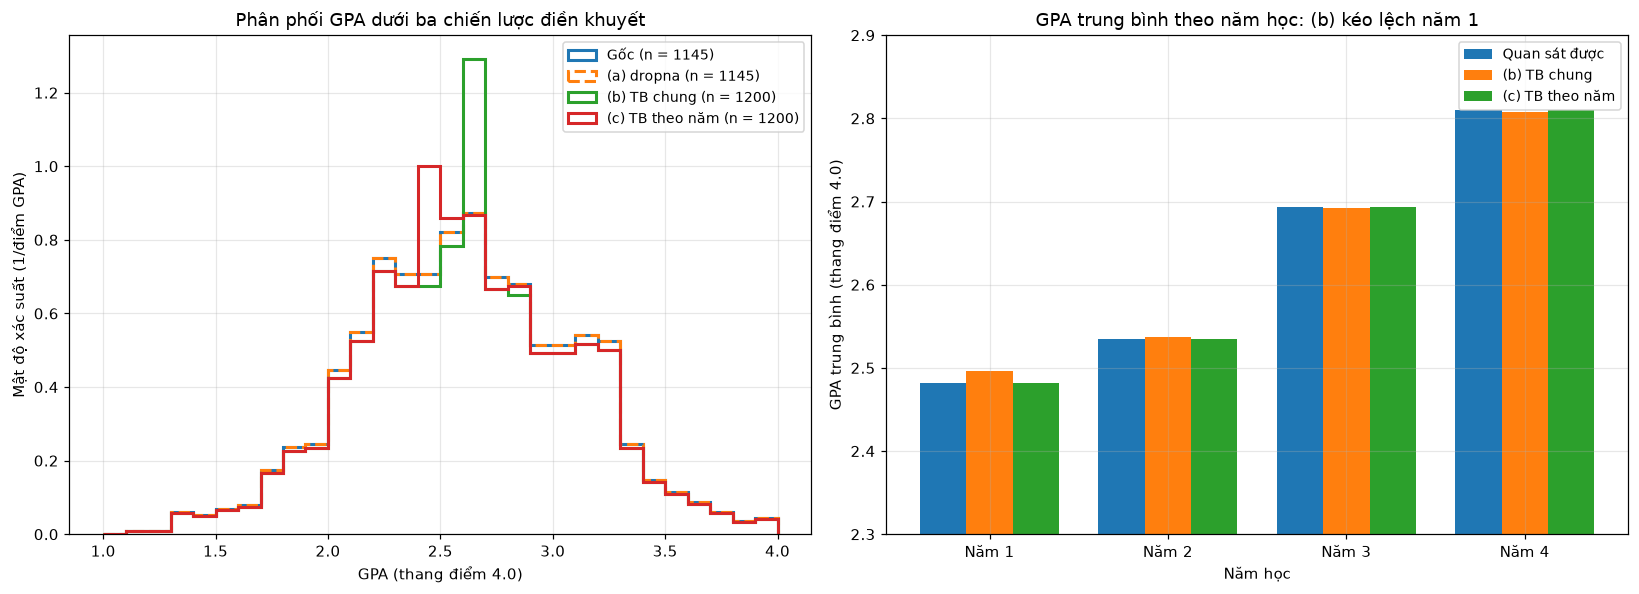

Task 4 ĐẠT.


In [16]:
# --- 4.3 Vẽ ba phân phối cùng với phân phối gốc, trên MỘT hình ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))

bins = np.linspace(1.0, 4.0, 31)
for s, lab, ls in [(original.dropna(), "Gốc (n = %d)" % original.count(), "-"),
                   (A, "(a) dropna (n = %d)" % len(A), "--"),
                   (B, "(b) TB chung (n = %d)" % len(B), "-"),
                   (C, "(c) TB theo năm (n = %d)" % len(C), "-")]:
    ax1.hist(s, bins=bins, histtype="step", density=True, linewidth=2, linestyle=ls, label=lab)
ax1.set_xlabel("GPA (thang điểm 4.0)")
ax1.set_ylabel("Mật độ xác suất (1/điểm GPA)")
ax1.set_title("Phân phối GPA dưới ba chiến lược điền khuyết")
ax1.legend(fontsize=9)

x = np.arange(len(by_year))
w = 0.26
ax2.bar(x - w, by_year["quan sát được"], w, label="Quan sát được")
ax2.bar(x,     by_year["(b) TB chung"],  w, label="(b) TB chung")
ax2.bar(x + w, by_year["(c) TB nhóm"],   w, label="(c) TB theo năm")
ax2.set_xticks(x)
ax2.set_xticklabels(["Năm %d" % y for y in by_year.index])
ax2.set_ylim(2.3, 2.9)
ax2.set_xlabel("Năm học")
ax2.set_ylabel("GPA trung bình (thang điểm 4.0)")
ax2.set_title("GPA trung bình theo năm học: (b) kéo lệch năm 1")
ax2.legend(fontsize=9)

fig.tight_layout()
fig.savefig("tuan02_so_sanh_dien_khuyet.png", dpi=300, bbox_inches="tight")
plt.show()

assert ax1.get_xlabel() and ax1.get_ylabel() and ax1.get_title()
assert ax2.get_xlabel() and ax2.get_ylabel() and ax2.get_title()
print("Task 4 ĐẠT.")

### Kết luận của bạn

1. Tỉ lệ thiếu `gpa` **không đều**: năm 1 **10,80%** (39/361), năm 2 **2,83%**, năm 3 **1,40%**, năm 4 **1,27%** — năm 1 gấp khoảng **8,5 lần** năm 4.
2. Nhóm thiếu nhiều nhất (năm 1) có GPA quan sát **thấp nhất: 2,4815**, so với 2,81 của năm 4. Nguy hiểm vì dữ liệu **thiếu có hệ thống** (không phải MCAR): cách xử lý nào bỏ qua cấu trúc này sẽ kéo kết quả về phía các khối năm trên có GPA cao hơn.
3. (a) làm **méo thành phần mẫu**: tỷ trọng sinh viên năm 1 rơi từ **0,3008 xuống 0,2812**. Trung bình 2,6148 của (a) thực chất là trung bình của một tập **thiếu đại diện năm 1** — nếu tính trung bình có trọng số đúng theo sĩ số từng năm thì GPA toàn trường còn thấp hơn một chút (≈ 2,61 như (c)).
4. (b) giữ trung bình chung 2,6148 nhưng gán **2,6148** cho 39 sinh viên năm 1 — cao hơn hẳn mức 2,48 của khối này — nên **đẩy GPA năm 1 lên 2,4959** (+0,014), đồng thời kéo nhẹ năm 3, năm 4 xuống. Nó "an toàn" ở tổng thể chỉ vì bảng tổng thể che mất sự sai lệch ở từng nhóm.
5. `std` giảm ở (b) và (c) (0,4871 → 0,4758 / 0,4766) vì 55 giá trị điền vào đều **nằm đúng ở trung bình** (chung hoặc nhóm), không có độ biến thiên nào. Ngoài ra `n` tăng lên 1200 như thể ta có thêm 55 quan sát thật. Hai điều này làm **khoảng tin cậy hẹp giả tạo** → ta tự tin quá mức, kiểm định dễ ra "có ý nghĩa" sai.
6. **(c) — điền theo nhóm `nam_hoc` — ít làm méo nhất**: giữ đúng trung bình từng năm (lệch = 0), giữ đủ 1200 dòng nên không làm lệch thành phần mẫu như (a), và trung bình toàn trường 2,6106 phản ánh đúng việc năm 1 (GPA thấp) chiếm 30% sĩ số. Nó vẫn làm `std` giảm nhẹ, nên khi cần suy diễn thống kê nên báo cáo kèm cảnh báo hoặc dùng phương pháp tốt hơn (điền theo nhiều biến / multiple imputation).
7. Giả thuyết: sinh viên **năm 1 mới nhập học (tháng 9/2022), nhiều em chưa kết thúc học kỳ đầu nên chưa có GPA tích lũy** — GPA "thiếu" vì **chưa tồn tại**, không phải vì bị mất. Nếu đúng vậy thì cách đúng nhất **không phải là điền**: nên để trống (hoặc gắn nhãn "chưa có GPA"), báo cáo riêng nhóm này và chỉ tính GPA trên sinh viên đã có điểm, nói rõ phạm vi. Bịa ra một con số GPA cho người chưa có điểm là tạo ra dữ liệu không có thật.

---
# Mở rộng (tự chọn) — dựng lại hai biểu đồ bằng Seaborn

Nếu còn thời gian: dựng lại biểu đồ **(1)** và **(2)** của Task 1 bằng Seaborn, rồi lập luận xem bản nào truyền đạt tốt hơn.

**Các bước**

1. `sns.histplot` cho phân phối GPA — thêm `hue` để tách theo `nam_hoc`. Đây là thứ matplotlib thuần làm được nhưng tốn khoảng mười dòng.
2. `sns.boxplot` cho GPA theo khoa.
3. Dùng `palette="colorblind"` — khoảng 8% nam giới bị mù màu đỏ-lục, và bảng màu mặc định không an toàn.
4. Vẫn phải đặt lại nhãn trục: **Seaborn đặt tên cột làm nhãn**, mà `gpa` hay `khoa` không phải là nhãn cho người đọc.

**Kết quả mong đợi.** Hai biểu đồ, lưu ở `tuan02_seaborn.png`, 300 dpi. Seaborn sẽ in một `MatplotlibDeprecationWarning` về tham số `vert` — đó là warning nội bộ của seaborn 0.13 với matplotlib 3.11, vô hại.

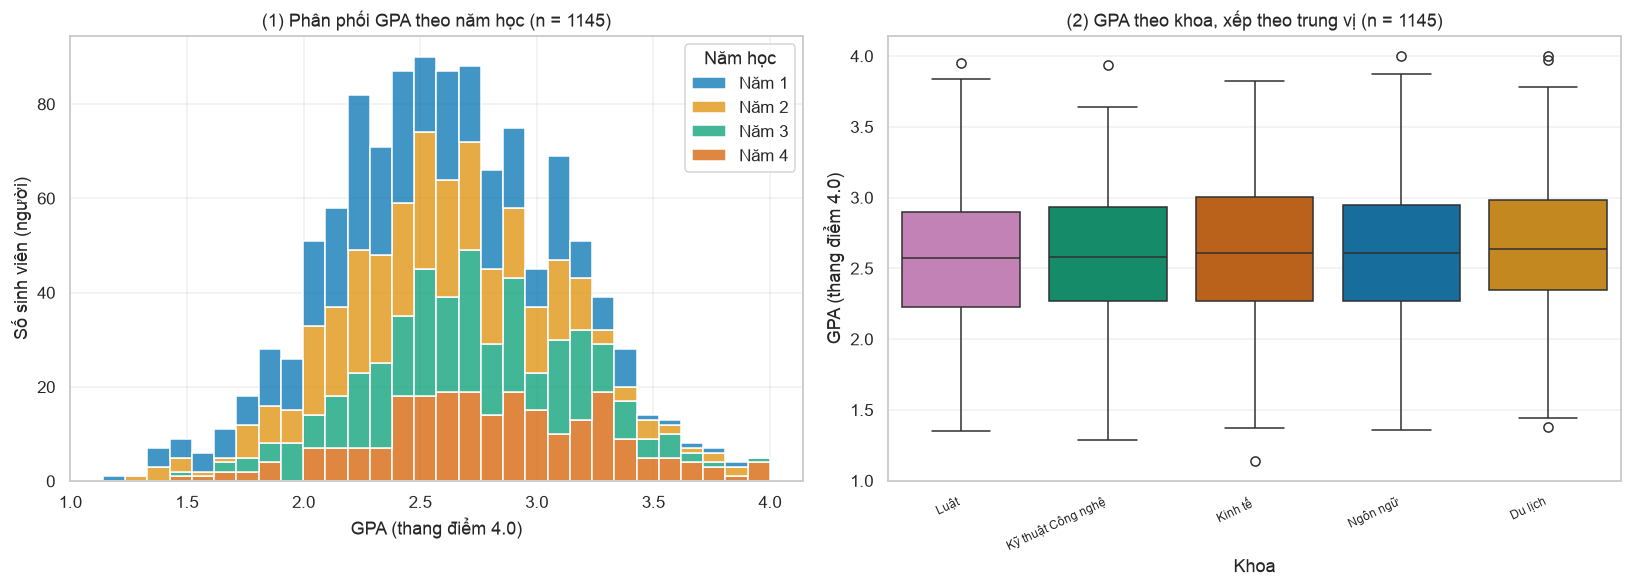

In [17]:
# --- Mở rộng (tự chọn): dựng lại biểu đồ (1) và (2) của Task 1 bằng Seaborn ---
# Lưu ý: seaborn 0.13 + matplotlib 3.11 sẽ in một MatplotlibDeprecationWarning về
# tham số `vert` ở boxplot. Đó là warning nội bộ của seaborn, vô hại, không phải lỗi của bạn.
sns.set_theme(style="whitegrid")
fig, (axa, axb) = plt.subplots(1, 2, figsize=(15, 5.5))

sv_plot = sv_gpa.assign(nam=("Năm " + sv_gpa["nam_hoc"].astype(str)))
sns.histplot(data=sv_plot, x="gpa", hue="nam", hue_order=["Năm 1", "Năm 2", "Năm 3", "Năm 4"],
             bins=30, multiple="stack", palette="colorblind", ax=axa)
axa.set_xlabel("GPA (thang điểm 4.0)")
axa.set_ylabel("Số sinh viên (người)")
axa.set_title("(1) Phân phối GPA theo năm học (n = %d)" % len(sv_plot))
axa.get_legend().set_title("Năm học")

order = sv_gpa.groupby("khoa")["gpa"].median().sort_values().index
sns.boxplot(data=sv_gpa, x="khoa", y="gpa", order=order, hue="khoa",
            palette="colorblind", legend=False, ax=axb)
axb.set_xlabel("Khoa")
axb.set_ylabel("GPA (thang điểm 4.0)")
axb.set_title("(2) GPA theo khoa, xếp theo trung vị (n = %d)" % len(sv_gpa))
plt.setp(axb.get_xticklabels(), rotation=25, ha="right", fontsize=8)

fig.tight_layout()
fig.savefig("tuan02_seaborn.png", dpi=300, bbox_inches="tight")
plt.show()
sns.set_theme(style="white")     # trả lại mặc định để không ảnh hưởng ô khác

### Bản nào truyền đạt tốt hơn?

1. Bản Seaborn cho thêm **chiều năm học** ngay trên histogram: histogram xếp chồng cho thấy đuôi trái (GPA thấp) chủ yếu là năm 1–2, còn đuôi phải nhiều năm 3–4 — điều bản Task 1 không thể hiện. Box plot được **xếp theo trung vị** và tô màu an toàn cho người mù màu.
2. Bản matplotlib thể hiện rõ hơn **hình dạng phân phối tổng thể** (một màu, có đường trung bình = 2,61), và box plot có **dấu trung bình** (`showmeans=True`). Histogram xếp chồng khó đọc hình dạng từng năm vì các lớp trên "ngồi" lên lớp dưới.
3. Mỗi biểu đồ khoảng **6–8 dòng** ở cả hai bản; riêng việc tách màu theo năm, matplotlib thuần sẽ tốn thêm ~10 dòng (lặp qua từng năm, chọn màu, `bottom=`, legend). Seaborn ngắn hơn cho những việc "chuẩn" (hue, palette, order), nhưng matplotlib cho kiểm soát chi tiết (đường trung bình, dấu mean, nhãn trên cột) — và dù dùng Seaborn vẫn phải tự đặt lại nhãn trục.
4. Gửi Ban Giám hiệu: chọn **bản Seaborn** cho histogram vì nó trả lời thẳng câu hỏi mà Ban Giám hiệu quan tâm — "GPA khác nhau theo năm học thế nào?" (năm 1 thấp hơn) — với bảng màu an toàn; kèm một câu chú thích diễn giải. Với box plot theo khoa, hai bản tương đương; ưu tiên bản xếp theo trung vị vì người đọc thấy ngay thứ hạng (dù khác biệt giữa các khoa rất nhỏ, ≈ 0,07 điểm).

---
# Danh sách kiểm tra trước khi nộp

Chạy **Kernel → Restart Kernel and Run All Cells** một lần cuối. Nếu có ô nào lỗi, notebook chưa nộp được.

**Tệp nộp**

- [x] `Tuan02_ThucHanh_VI.ipynb` — chạy hết từ trên xuống, không ô nào lỗi
- [x] `tuan02_6bieudo.png` — bảng 6 biểu đồ, 300 dpi (~0,9 MB)
- [x] `banhang_sach.csv` — 900 dòng × 8 cột
- [x] `tuan02_so_sanh_dien_khuyet.png` — hình so sánh của Task 4

**Nội dung**

- [x] **Task 1** — đủ 6 biểu đồ; **mọi** trục có nhãn kèm đơn vị; colorbar của heatmap có nhãn; ô tự kiểm tra in `ĐẠT`
- [x] **Task 1** — đã viết 6 câu nhận định, mỗi câu nói một điều dữ liệu cho biết
- [x] **Task 2** — `profile()` trả về DataFrame, đúng 1 dòng/cột, chạy được trên cả hai tệp và cả trường hợp biên
- [x] **Task 3** — cả 8 bước chạy qua `assert`; bước 3.8 báo **0/900** dòng lệch
- [x] **Task 3** — **Nhật ký làm sạch điền đầy đủ**, mỗi dòng có lý do thật, và đã trả lời cả ba câu hỏi cuối
- [x] **Task 3** — đã viết lập luận cho ba quyết định: ngày `31/02`, hai cột thiếu, bảy dòng ngoại lai
- [x] **Task 4** — đã đo tỉ lệ thiếu theo `nam_hoc` **trước khi** điền; có bảng so sánh theo từng năm; có kết luận nêu rõ cách nào ít méo nhất và vì sao

**Hai câu tự hỏi trước khi bấm nộp**

1. Nếu xóa hết kết quả và gửi notebook cho bạn cùng lớp, người đó chạy lại có ra **đúng** những con số này không?
2. Trong nhật ký làm sạch, có dòng nào mà lý do chỉ là "để dữ liệu sạch hơn" không? Nếu có, dòng đó chưa hoàn thành.

> **Nhắc lại lần cuối.** Nhật ký làm sạch được chấm ngang với phần code. Một notebook chạy hoàn hảo nhưng không giải thích được vì sao lại quyết định như vậy thì không phải một bài phân tích — nó chỉ là một chuỗi thao tác.